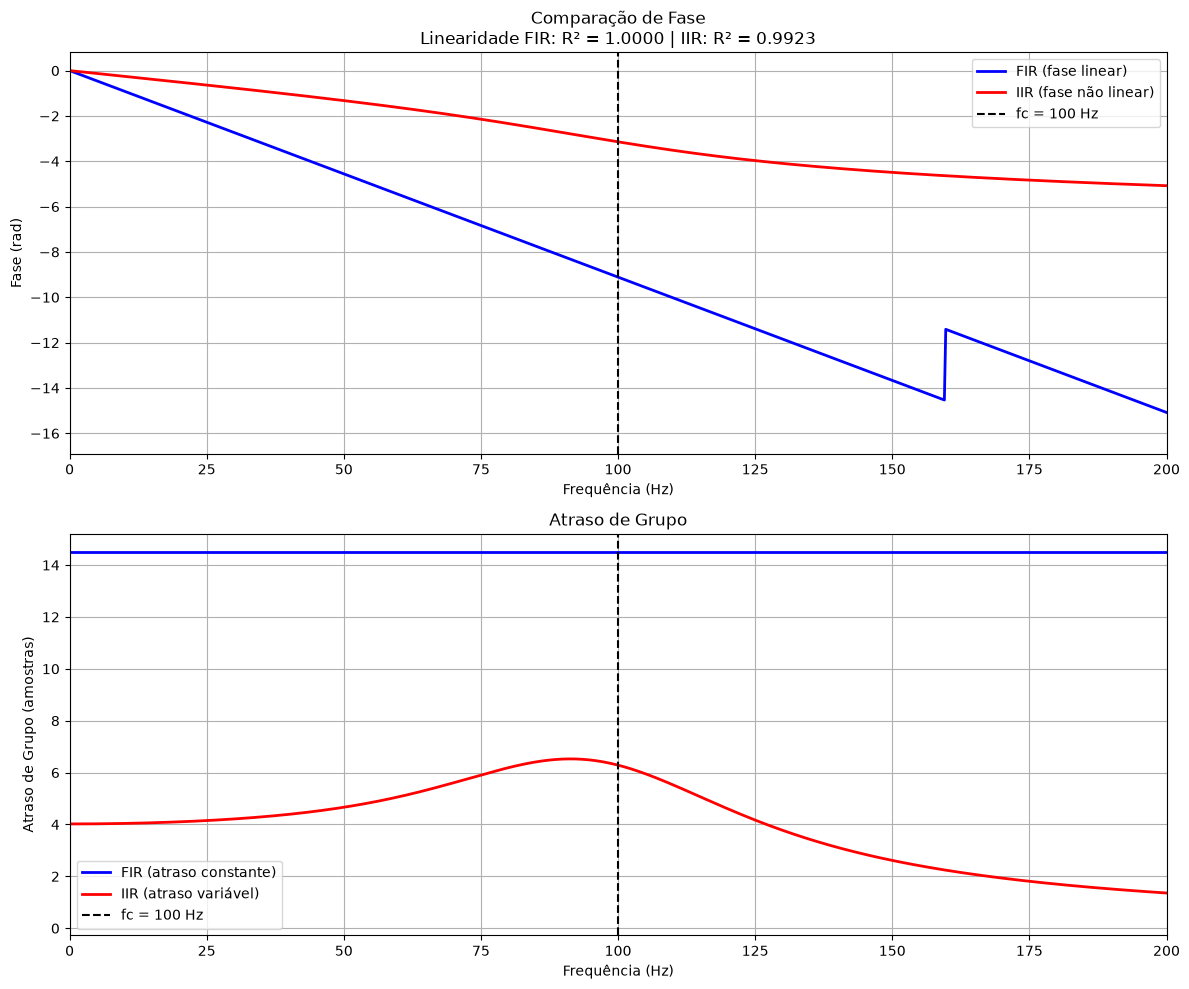

Linearidade da fase FIR (R²): 1.0000 (próximo de 1.0 = fase linear)
Linearidade da fase IIR (R²): 0.9923 (afastado de 1.0 = fase não linear)
Atraso de grupo FIR (médio): 14.50 amostras
Atraso de grupo IIR (médio): 5.00 amostras


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
fs = 1000
fc = 100  # Hz

# Projeto de filtros FIR e IIR
ordem_fir = 30
b_fir = signal.firwin(ordem_fir, fc, fs=fs, window='hamming')
b_iir, a_iir = signal.butter(4, fc, fs=fs, btype='low')

# Respostas em frequência
w_fir, h_fir = signal.freqz(b_fir, [1.0], worN=2000, fs=fs)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=2000, fs=fs)

# Fase e atraso de grupo
fase_fir = np.unwrap(np.angle(h_fir))
fase_iir = np.unwrap(np.angle(h_iir))
_, gd_fir = signal.group_delay((b_fir, [1.0]), w=w_fir, fs=fs)
_, gd_iir = signal.group_delay((b_iir, a_iir), w=w_iir, fs=fs)

# Cálculo da linearidade da fase
def linearidade_fase(fase, w, fc, fs):
    # Regressão linear na banda de passagem
    idx = w < fc
    if np.sum(idx) > 1:
        coef = np.polyfit(w[idx], fase[idx], 1)
        # Coeficiente de determinação R²
        pred = np.polyval(coef, w[idx])
        residuos = fase[idx] - pred
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((fase[idx] - np.mean(fase[idx]))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        return r2, coef[0]
    return 0, 0

r2_fir, slope_fir = linearidade_fase(fase_fir, w_fir, fc, fs)
r2_iir, slope_iir = linearidade_fase(fase_iir, w_iir, fc, fs)

# Gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Fase
axes[0].plot(w_fir, fase_fir, 'b', label='FIR (fase linear)', linewidth=2)
axes[0].plot(w_iir, fase_iir, 'r', label='IIR (fase não linear)', linewidth=2)
axes[0].axvline(fc, color='k', linestyle='--', label=f'fc = {fc} Hz')
axes[0].set_xlabel('Frequência (Hz)')
axes[0].set_ylabel('Fase (rad)')
axes[0].set_title(f'Comparação de Fase\nLinearidade FIR: R² = {r2_fir:.4f} | IIR: R² = {r2_iir:.4f}')
axes[0].set_xlim(0, 200)
axes[0].legend()
axes[0].grid()

# Atraso de grupo
axes[1].plot(w_fir, gd_fir, 'b', label='FIR (atraso constante)', linewidth=2)
axes[1].plot(w_iir, gd_iir, 'r', label='IIR (atraso variável)', linewidth=2)
axes[1].axvline(fc, color='k', linestyle='--', label=f'fc = {fc} Hz')
axes[1].set_xlabel('Frequência (Hz)')
axes[1].set_ylabel('Atraso de Grupo (amostras)')
axes[1].set_title('Atraso de Grupo')
axes[1].set_xlim(0, 200)
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

print(f"Linearidade da fase FIR (R²): {r2_fir:.4f} (próximo de 1.0 = fase linear)")
print(f"Linearidade da fase IIR (R²): {r2_iir:.4f} (afastado de 1.0 = fase não linear)")
print(f"Atraso de grupo FIR (médio): {np.mean(gd_fir[w_fir < fc]):.2f} amostras")
print(f"Atraso de grupo IIR (médio): {np.mean(gd_iir[w_iir < fc]):.2f} amostras")

# Discussão dos Resultados
O filtro FIR apresenta fase linear, caracterizada por uma relação linear entre fase e frequência e atraso de grupo constante. Isso resulta em preservação da forma do sinal processado. O filtro IIR, por sua vez, apresenta fase não linear e atraso de grupo variável, o que pode causar distorção de fase e alteração da forma de onda. O coeficiente R² próximo de 1.0 para o FIR confirma a linearidade da fase na banda de passagem.